## Introduction

Booking cancellations represent a major challenge for hotels, as flexible cancellation policies introduce uncertainty in revenue forecasting and capacity planning. Using historical booking data, this project applies supervised machine learning to predict whether a reservation will be canceled and to identify the key factors driving cancellation behavior.

**The ultimate goal** is to provide actionable insights that support more effective revenue management and operational decision-making.

##1. Setup and Imports

In [5]:
# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Modeling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, RocCurveDisplay, ConfusionMatrixDisplay
)

# Reproducibility
RANDOM_STATE = 42

## 2. Loading Data

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
DATA_PATH = "/content/drive/MyDrive/ML Team Project/hotel_booking.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (119390, 36)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


## 2.1 Quick Data Check

shape & columns



In [8]:
print("Shape:", df.shape)
print("\nColumns:")
display(df.columns.tolist())

Shape: (119390, 36)

Columns:


['hotel',
 'is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_month',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'reserved_room_type',
 'assigned_room_type',
 'booking_changes',
 'deposit_type',
 'agent',
 'company',
 'days_in_waiting_list',
 'customer_type',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests',
 'reservation_status',
 'reservation_status_date',
 'name',
 'email',
 'phone-number',
 'credit_card']

Data types & missing values

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [10]:
missing_pct = df.isna().mean().sort_values(ascending=False)
display(missing_pct[missing_pct > 0])

,0
company,0.943069
agent,0.136862
country,0.004087
children,0.000034


In [12]:
df.duplicated().sum()

np.int64(0)

Check impossible values (counts)

In [13]:
# Guests
(df["adults"] < 0).sum(), (df["children"] < 0).sum(), (df["babies"] < 0).sum()

(np.int64(0), np.int64(0), np.int64(0))

In [14]:
# Stays
(df["stays_in_week_nights"] < 0).sum(), (df["stays_in_weekend_nights"] < 0).sum()

(np.int64(0), np.int64(0))

Bookings with zero guests

In [15]:
zero_guests = df[(df["adults"] + df["children"] + df["babies"]) == 0]
zero_guests.shape

(180, 36)

In [16]:
df = df[(df["adults"] + df["children"] + df["babies"]) > 0]
print("After removing zero-guest bookings:", df.shape)

After removing zero-guest bookings: (119206, 36)


ADR sanity check

In [17]:
df["adr"].describe()

,adr
count,119206.000000
mean,101.971519
std,50.432866
min,-6.380000
25%,69.500000
50%,94.950000
75%,126.000000
max,5400.000000


In [18]:
(df["adr"] < 0).sum()

np.int64(1)

Leakage Check

In [19]:
leakage_cols = [
    "reservation_status",
    "reservation_status_date"
]

[col for col in leakage_cols if col in df.columns]

['reservation_status', 'reservation_status_date']

Light Feature Hygiene


In [20]:
# arrival date as numeric (already split, but confirm types)
df[["arrival_date_year", "arrival_date_week_number", "arrival_date_day_of_month"]].head()

,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month
0,2015,27,1
1,2015,27,1
2,2015,27,1
3,2015,27,1
4,2015,27,1


In [21]:
#Check categorical cardinality (for modeling later)
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    print(col, ":", df[col].nunique())

hotel : 2
arrival_date_month : 12
meal : 5
country : 177
market_segment : 7
distribution_channel : 5
reserved_room_type : 9
assigned_room_type : 11
deposit_type : 3
customer_type : 4
reservation_status : 3
reservation_status_date : 926
name : 81403
email : 115717
phone-number : 119206
credit_card : 9000


At this stage, no additional data cleaning is required beyond removing invalid zero-guest bookings and identifying leakage variables. Further preprocessing steps such as imputation, scaling, and encoding will be handled within the modeling pipeline to avoid data leakage.

## EDA

The goal is to understand how booking characteristics differ between canceled and non-canceled reservations.

Exploratory data analysis is necessary to understand how key booking characteristics differ between canceled and non-canceled reservations. EDA helps validate data quality, identify meaningful predictors, and ensure that observed relationships are consistent with real-world booking behavior before formal modeling.

We will:

  Ask one question per plot

  Draw one conclusion per plot

  Keep only plots that inform modeling or business insight

Q1 Overall Cancellation Rate

In [22]:
df["is_canceled"].value_counts()
df["is_canceled"].value_counts(normalize=True)

,proportion
is_canceled,
0,0.629255
1,0.370745


From the output:

62.96% of bookings are not canceled

37.04% of bookings are canceled

So roughly 1 out of every 3 bookings ends in cancellation


Approximately 37% of hotel bookings are canceled, indicating that cancellation is a frequent and economically meaningful outcome rather than a rare event.

Q2 Lead time vs Cancellation

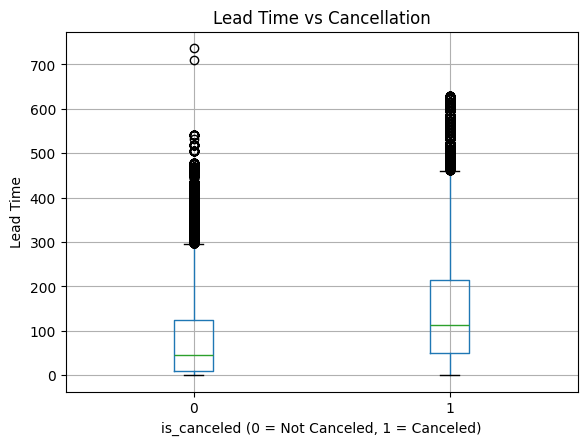

In [23]:
df.boxplot(column="lead_time", by="is_canceled")
plt.title("Lead Time vs Cancellation")
plt.suptitle("")
plt.xlabel("is_canceled (0 = Not Canceled, 1 = Canceled)")
plt.ylabel("Lead Time")
plt.show()

Canceled bookings (is_canceled = 1) have:

* A much higher median lead time
* A wider interquartile range

Non-canceled bookings (is_canceled = 0):
* Are concentrated at shorter lead times
* Long lead times appear far more frequently among canceled bookings

Long lead time (booked far in advance) → higher cancellation rate

Short lead time (booked close to arrival) → lower cancellation rate

Customers who book hotels far in advance are more likely to cancel, whereas customers who book closer to the arrival date exhibit stronger commitment and lower cancellation risk.


Q3 ADR (Price) vs Cancellation

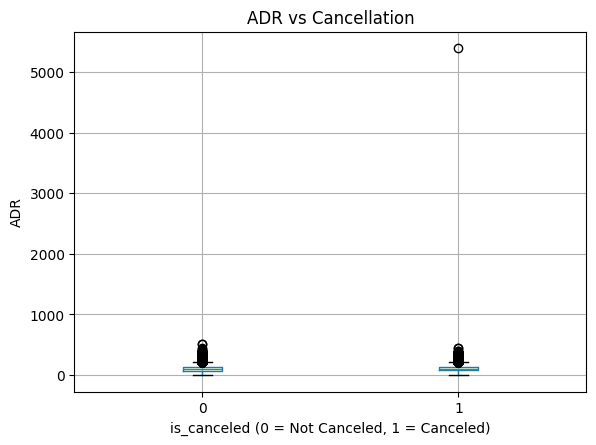

In [24]:
df.boxplot(column="adr", by="is_canceled")
plt.title("ADR vs Cancellation")
plt.suptitle("")
plt.xlabel("is_canceled (0 = Not Canceled, 1 = Canceled)")
plt.ylabel("ADR")
plt.show()

Price alone does not sharply separate canceled vs non-canceled bookings
* The ADR distributions for canceled (1) and not canceled (0) bookings overlap heavily

* The median ADR for canceled bookings is slightly higher, but the difference is modest

* There are extreme outliers, especially on the canceled side (very high ADR values)

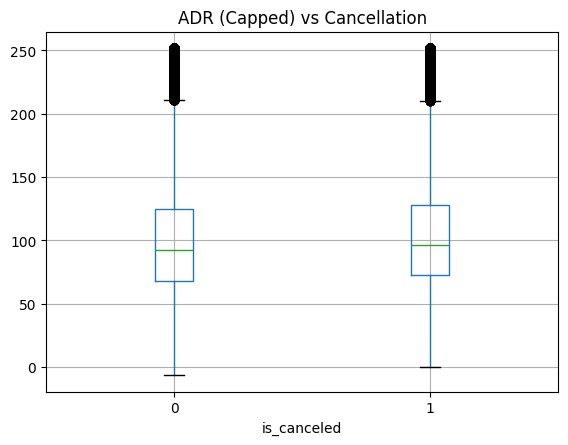

In [25]:
cap = df["adr"].quantile(0.99)
df.assign(adr_capped=df["adr"].clip(upper=cap)).boxplot(
    column="adr_capped", by="is_canceled"
)
plt.title("ADR (Capped) vs Cancellation")
plt.suptitle("")
plt.show()

From the capped ADR boxplot:

* The median ADR for canceled bookings (is_canceled = 1) is slightly higher than for non-canceled bookings

* The interquartile ranges overlap substantially

* The overall ADR distributions remain very similar between the two groups

Even after capping, there is no sharp separation between canceled and non-canceled bookings

Bookings that are eventually canceled tend to have slightly higher average daily rates (ADR), but the substantial overlap in price distributions indicates that ADR alone is a weak predictor of cancellation.

Q4 Repeat Guest vs Cancellation Rate

In [26]:
df.groupby("is_repeated_guest")["is_canceled"].mean()

,is_canceled
is_repeated_guest,
0,0.378039
1,0.146471


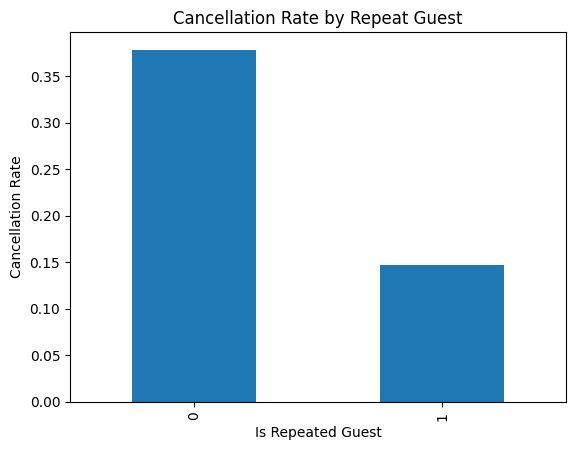

In [27]:
df.groupby("is_repeated_guest")["is_canceled"].mean().plot(kind="bar")
plt.title("Cancellation Rate by Repeat Guest")
plt.xlabel("Is Repeated Guest")
plt.ylabel("Cancellation Rate")
plt.show()

From the output:

Non-repeat guests (is_repeated_guest = 0)

* Cancellation rate ≈ 37.8%

Repeat guests (is_repeated_guest = 1)

* Cancellation rate ≈ 14.6%

Repeat guests exhibit a substantially lower cancellation rate than non-repeat guests, suggesting that customer loyalty is strongly associated with higher booking commitment.

Q5 Distribution Channel vs Cancellation

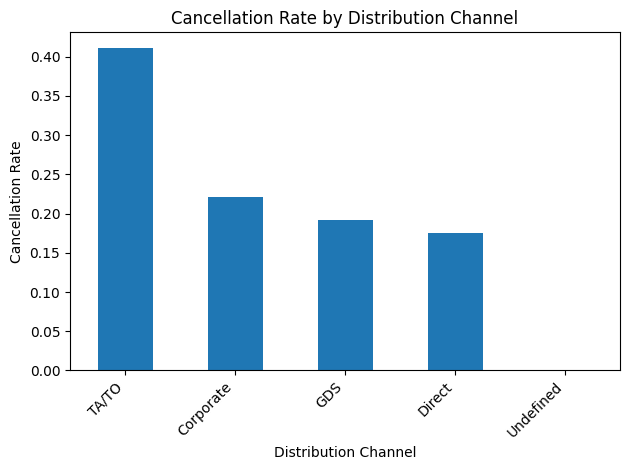

In [28]:
channel_cancel = (
    df.groupby("distribution_channel")["is_canceled"]
      .mean()
      .sort_values(ascending=False)
)

channel_cancel.plot(kind="bar")
plt.title("Cancellation Rate by Distribution Channel")
plt.xlabel("Distribution Channel")
plt.ylabel("Cancellation Rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

From the bar chart:

* TA/TO (Travel Agents / Tour Operators): Highest cancellation rate (≈ 41%)

* Corporate: Moderate cancellation rate (≈ 22%)

* GDS: Slightly lower (≈ 19%)

* Direct bookings: Lowest among major channels (≈ 17%)

* Undefined: Very small volume (interpret with caution)

Cancellation rates vary substantially across distribution channels, with bookings made through travel agents and tour operators exhibiting the highest cancellation risk, while direct bookings show the lowest cancellation rates.